In [295]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import yfinance as yf 

# Instructions

1. Download WTI Crude Oil(DCOILWTICO) data from FRED from '2022-08-29' to '2023-11-29', read the csv using `pd.read_csv()`, clean the dataset
2. Name this .ipynb file `LastName_FirstName_HW0.ipynb`
3. Do the problems
3. Make sure the notebook runs without errors after restarting your kernel
4. Submit this .ipynb file to Blackboard in the Homework 0 file

* **Note**: Units are in Dollars per Barrel,

In [298]:
import pandas as pd

df = pd.read_csv('DCOILWTICO.csv')
df.head()

,observation_date,DCOILWTICO
0,2022-08-29,97.40
1,2022-08-30,92.08
2,2022-08-31,90.09
3,2022-09-01,87.09
4,2022-09-02,87.29


In [299]:
df.tail()

,observation_date,DCOILWTICO
323,2023-11-23,NaN
324,2023-11-24,74.83
325,2023-11-27,74.46
326,2023-11-28,76.09
327,2023-11-29,77.56


In [300]:
df.isnull().sum()

observation_date     0
DCOILWTICO          14
dtype: int64

As we can see here we have missing data in 14 rows in the DCOILWTICO column. As such to deal with it we shall use `ffill` the forward fill method to deal with it by carrying forward the last observed non-missing value.

In [302]:
# Forward fill missing values in a specific col
df_cleaned = df.ffill(axis = 0)

In [303]:
df_cleaned.isnull().sum()

observation_date    0
DCOILWTICO          0
dtype: int64

## Exploratory Data Analysis

In [305]:
df_cleaned.head()

,observation_date,DCOILWTICO
0,2022-08-29,97.40
1,2022-08-30,92.08
2,2022-08-31,90.09
3,2022-09-01,87.09
4,2022-09-02,87.29


In [306]:
df_cleaned.tail()

,observation_date,DCOILWTICO
323,2023-11-23,76.80
324,2023-11-24,74.83
325,2023-11-27,74.46
326,2023-11-28,76.09
327,2023-11-29,77.56


Let's rename the column of `DCOILWTICO` to `price_per_barrel` to make things clearer

In [308]:
df_cleaned.rename(columns={'DCOILWTICO': 'price_per_barrel'}, inplace=True)
df_cleaned.head()

,observation_date,price_per_barrel
0,2022-08-29,97.40
1,2022-08-30,92.08
2,2022-08-31,90.09
3,2022-09-01,87.09
4,2022-09-02,87.29


# Part A — Forwards: Hedge an Oil Producer

**Scenario:** You expect to sell **5,000 barrels** of oil in **3 months**. Compare potential outcomes:
- **Unhedged revenue:** `5,000 × S_T`
- **Hedged revenue with short forward:** `5,000 × K`

**Tasks**
1. Make a copy of your dataframe and slice it from '2022-08-29' to '2022-11-29'
- Assume Forward Price at $t_0=S_0$
- `T = '2022-11-29'`
2. Plot WTI spot path from `t0` to `T` and report `S_0` and `S_T`.
3. Compute P&L for **short** forward per barrel and scaled by 5,000 bbl.
4. Compare hedged vs unhedged revenue and discuss hedge effectiveness (2–4 sentences).
5. Plot the theoretical P&L of a long forward and a short forward with $K = S_0$


### Task 1. Make a copy of your dataframe and slice it from '2022-08-29' to '2022-11-29'

Made the copy as requested

In [312]:
df_A = df_cleaned.copy()
df_A.head()

,observation_date,price_per_barrel
0,2022-08-29,97.40
1,2022-08-30,92.08
2,2022-08-31,90.09
3,2022-09-01,87.09
4,2022-09-02,87.29


We shall do the slicing from '2022-08-29' to '2022-11-29' but before that we need to check the datatype

In [314]:
df_A.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 328 entries, 0 to 327
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   observation_date  328 non-null    object 
 1   price_per_barrel  328 non-null    float64
dtypes: float64(1), object(1)
memory usage: 5.3+ KB


It appears our data wasn't in the right format to conduct the slicing so we need to convert it to the appropriate format.

In [316]:
# Convert the date to datetime64
df_A['observation_date'] = pd.to_datetime(df_A['observation_date'], format='%Y-%m-%d')
df_A.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 328 entries, 0 to 327
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   observation_date  328 non-null    datetime64[ns]
 1   price_per_barrel  328 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 5.3 KB


In [317]:
df_A.head()

,observation_date,price_per_barrel
0,2022-08-29,97.40
1,2022-08-30,92.08
2,2022-08-31,90.09
3,2022-09-01,87.09
4,2022-09-02,87.29


Now we do the slicing from '2022-08-29' to '2022-11-29'

In [319]:
# Filter data between two dates
filtered_df = df_A.loc[(df_A['observation_date'] >= '2022-08-29')
                     & (df_A['observation_date'] < '2022-11-29')]
# Display
filtered_df

,observation_date,price_per_barrel
0,2022-08-29,97.40
1,2022-08-30,92.08
2,2022-08-31,90.09
3,2022-09-01,87.09
4,2022-09-02,87.29
...,...,...
61,2022-11-22,80.83
62,2022-11-23,77.93
63,2022-11-24,77.93
64,2022-11-25,76.45


### Task 2. Plot WTI spot path from `t0` to `T` and report `S_0` and `S_T`.

Plot WTI spot path from `t0` to `T`

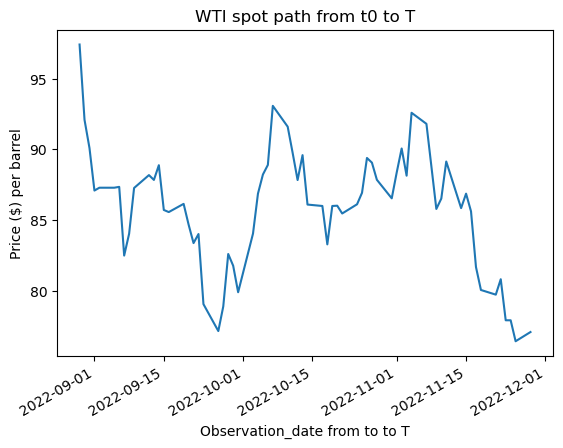

In [322]:
# Plot the spot path from t0 to T and report S_0 and S_T
fig, ax = plt.subplots()
ax.plot(filtered_df.observation_date, filtered_df.price_per_barrel)
ax.xaxis_date()     # interpret the x-axis values as dates
fig.autofmt_xdate() # make space for and rotate the x-axis tick labels

# Add in labels to improve readability
plt.title('WTI spot path from t0 to T');
plt.xlabel('Observation_date from to to T')
plt.ylabel('Price ($) per barrel')

plt.show()

Report `S_0` and `S_T`.
- Assume Forward Price at $t_0=S_0$

In [324]:
# To report S_0
S_0 = filtered_df.price_per_barrel # S_0 refers to the price per barrel for the particular day depending which day it is
S_0

0     97.40
1     92.08
2     90.09
3     87.09
4     87.29
      ...  
61    80.83
62    77.93
63    77.93
64    76.45
65    77.10
Name: price_per_barrel, Length: 66, dtype: float64

- `T = '2022-11-29'`

In [326]:
len(S_0)

66

In [327]:
# To report S_T
# S_T = filtered_df.tail(1).price_per_barrel
S_T = filtered_df.loc[len(S_0)-1:len(S_0), 'price_per_barrel']
S_T

65    77.1
Name: price_per_barrel, dtype: float64

### Task 3. Compute P&L for **short** forward per barrel and scaled by 5,000 bbl.

P&L for short forward: $\text{P\&L} = K - S_T$
- Assume Forward Price at $t_0=S_0$
- `T = '2022-11-29'`

In [330]:
print(S_0)

0     97.40
1     92.08
2     90.09
3     87.09
4     87.29
      ...  
61    80.83
62    77.93
63    77.93
64    76.45
65    77.10
Name: price_per_barrel, Length: 66, dtype: float64


In [331]:
print(S_T)

65    77.1
Name: price_per_barrel, dtype: float64


In [332]:
# Let us compute the daily P&L for short forward per barrel first
pd.options.mode.copy_on_write = True
filtered_df["PnL_Daily_per_barrel"] = filtered_df.apply(lambda row: row.price_per_barrel - 
                                  (S_T), axis = 1)
filtered_df.head()

,observation_date,price_per_barrel,PnL_Daily_per_barrel
0,2022-08-29,97.40,20.30
1,2022-08-30,92.08,14.98
2,2022-08-31,90.09,12.99
3,2022-09-01,87.09,9.99
4,2022-09-02,87.29,10.19


Now let us scale by 5,000 barrels.

In [334]:
filtered_df["PnL_Daily"] = filtered_df.apply(lambda row: row.PnL_Daily_per_barrel * 5000, axis = 1)
filtered_df.head()

,observation_date,price_per_barrel,PnL_Daily_per_barrel,PnL_Daily
0,2022-08-29,97.40,20.30,101500.0
1,2022-08-30,92.08,14.98,74900.0
2,2022-08-31,90.09,12.99,64950.0
3,2022-09-01,87.09,9.99,49950.0
4,2022-09-02,87.29,10.19,50950.0


### Task 4. Compare hedged vs unhedged revenue and discuss hedge effectiveness (2–4 sentences).

Comparing the hedged and unhedged revenue. If we didn't hedge the price of barrel, and if choose to buy the 5000 barrels on the day itself. We would be charged the market price and make a cummulative Profit and Loss of $0.

However, if we did use the hedging by shorting the forward like what the question suggested our overall Profit and Loss would be **\\$2888000.000000002**. Which translates to cost savings of up to **\\$2888000.000000002** instead of being charged the market price.

Assuming we did it right out of the 66 days, 64 resulted in a profit, 1 was a loss and 1 was neither. The one where the Profit and Loss is 0 is because we designed S_T = 77.10 which was the last day where `T = '2022-11-29'`. Since our overall Profit and Loss is approximately $2888000 the total profits far outweight the loss.

In [336]:
Total = filtered_df['PnL_Daily'].sum()
print(f'Overall Profit and Loss for the period of 2022-08-29 to 2022-11-29 is ${Total}')

Overall Profit and Loss for the period of 2022-08-29 to 2022-11-29 is $2888000.000000002


In [337]:
np.sign(filtered_df.PnL_Daily).value_counts()

PnL_Daily
 1.0    64
-1.0     1
 0.0     1
Name: count, dtype: int64

### Task 5: Plot the theoretical P&L of a long forward and a short forward with $K = S_0$


In [339]:
filtered_df.rename(columns={'PnL_Daily': 'PnL_Daily_Short_Forward'}, inplace=True)
filtered_df.rename(columns={'PnL_Daily_per_barrel': 'PnL_Daily_per_barrel_Short_Forward'}, inplace=True)

filtered_df.head()

,observation_date,price_per_barrel,PnL_Daily_per_barrel_Short_Forward,PnL_Daily_Short_Forward
0,2022-08-29,97.40,20.30,101500.0
1,2022-08-30,92.08,14.98,74900.0
2,2022-08-31,90.09,12.99,64950.0
3,2022-09-01,87.09,9.99,49950.0
4,2022-09-02,87.29,10.19,50950.0


P&L for long forward: $\text{P\&L} = S_T - K$
- Assume Forward Price at $t_0=S_0$
- `T = '2022-11-29'`

In [341]:
# Let us compute the daily P&L for short forward per barrel first
pd.options.mode.copy_on_write = True
filtered_df["PnL_Daily_per_barrel_Long_Forward"] = filtered_df.apply(lambda row: (S_T)- row.price_per_barrel, axis = 1)
filtered_df.head()

,observation_date,price_per_barrel,PnL_Daily_per_barrel_Short_Forward,PnL_Daily_Short_Forward,PnL_Daily_per_barrel_Long_Forward
0,2022-08-29,97.40,20.30,101500.0,-20.30
1,2022-08-30,92.08,14.98,74900.0,-14.98
2,2022-08-31,90.09,12.99,64950.0,-12.99
3,2022-09-01,87.09,9.99,49950.0,-9.99
4,2022-09-02,87.29,10.19,50950.0,-10.19


In [342]:
filtered_df["PnL_Daily_Long_Forward"] = filtered_df.apply(lambda row: row.PnL_Daily_per_barrel_Long_Forward * 5000, axis = 1)
filtered_df.head()

,observation_date,price_per_barrel,PnL_Daily_per_barrel_Short_Forward,PnL_Daily_Short_Forward,PnL_Daily_per_barrel_Long_Forward,PnL_Daily_Long_Forward
0,2022-08-29,97.40,20.30,101500.0,-20.30,-101500.0
1,2022-08-30,92.08,14.98,74900.0,-14.98,-74900.0
2,2022-08-31,90.09,12.99,64950.0,-12.99,-64950.0
3,2022-09-01,87.09,9.99,49950.0,-9.99,-49950.0
4,2022-09-02,87.29,10.19,50950.0,-10.19,-50950.0


#### Theoretical PnL for Long Forward

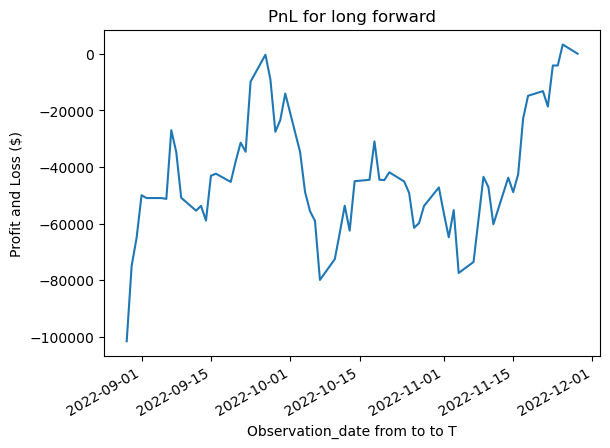

In [344]:
# This is the theoretical PnL for long forward

fig, ax = plt.subplots()
ax.plot(filtered_df.observation_date, filtered_df.PnL_Daily_Long_Forward)
ax.xaxis_date()     # interpret the x-axis values as dates
fig.autofmt_xdate() # make space for and rotate the x-axis tick labels

# Add in labels to improve readability
plt.title('PnL for long forward');
plt.xlabel('Observation_date from to to T')
plt.ylabel('Profit and Loss ($)')

plt.show()

#### Theoretical PnL for Short forward

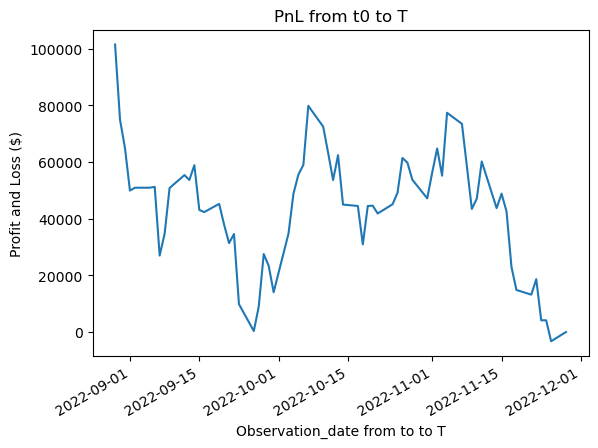

In [346]:
# This is the theoretical PnL for short forward

fig, ax = plt.subplots()
ax.plot(filtered_df.observation_date, filtered_df.PnL_Daily_Short_Forward)
ax.xaxis_date()     # interpret the x-axis values as dates
fig.autofmt_xdate() # make space for and rotate the x-axis tick labels

# Add in labels to improve readability
plt.title('PnL from t0 to T');
plt.xlabel('Observation_date from to to T')
plt.ylabel('Profit and Loss ($)')

plt.show()

# Part B: Swaps

Swap terms: 
- Notional 100,000 gallons of WTI Crude
- Monthly Swap payments ($/g)-->(42g/barrel)

    - Heating Oil company pays a fixed amount, \$1.99 to 3rd party(bank, intermediary)
    - Bank pays the average monthly oil price/gallon to the heating company(floating)
Tasks:
1. Convert the dollars-per-barrel to dollars-per-gallon(42 gallons per barrel). Create a new column.
2. Compute the average monthly $/G for each month
3. Compute the realized net payment for each month for both sides of the swap
    - plot the net payments for both parties vs time
4. Plot the theoretical P&L of the fixed-for-floating swap position

In [348]:
df_B = df_cleaned.copy()
df_B.head()

,observation_date,price_per_barrel
0,2022-08-29,97.40
1,2022-08-30,92.08
2,2022-08-31,90.09
3,2022-09-01,87.09
4,2022-09-02,87.29


In [349]:
type(df_B)

pandas.core.frame.DataFrame

### Task 1: Convert the dollars-per-barrel to dollars-per-gallon(42 gallons per barrel). Create a new column.

As 1 barrel contains 42 gallons. To convert the dollars-per-barrel to dollars-per-gallon(42 gallons per barrel). Create a new column.

In [352]:
# Let us compute the daily P&L for short forward per barrel first
pd.options.mode.copy_on_write = True
df_B["dollars_per_gallon"] = df_B.apply(lambda row: row.price_per_barrel /42, axis = 1)
df_B.head()

,observation_date,price_per_barrel,dollars_per_gallon
0,2022-08-29,97.40,2.319048
1,2022-08-30,92.08,2.192381
2,2022-08-31,90.09,2.145000
3,2022-09-01,87.09,2.073571
4,2022-09-02,87.29,2.078333


### Task 2: Compute the average monthly $/G for each month

In [354]:
df_B.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 328 entries, 0 to 327
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   observation_date    328 non-null    object 
 1   price_per_barrel    328 non-null    float64
 2   dollars_per_gallon  328 non-null    float64
dtypes: float64(2), object(1)
memory usage: 7.8+ KB


In [355]:
# Convert the date to datetime64
df_B['observation_date'] = pd.to_datetime(df_A['observation_date'], format='%Y-%m-%d')
df_B.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 328 entries, 0 to 327
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   observation_date    328 non-null    datetime64[ns]
 1   price_per_barrel    328 non-null    float64       
 2   dollars_per_gallon  328 non-null    float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 7.8 KB


In [356]:
df_B_monthly = df_B.groupby(pd.PeriodIndex(df_B['observation_date'], freq="M"))['dollars_per_gallon'].mean()
df_B_monthly

observation_date
2022-08    2.218810
2022-09    2.009426
2022-10    2.084637
2022-11    2.001851
2022-12    1.823323
2023-01    1.864199
2023-02    1.828726
2023-03    1.744710
2023-04    1.893071
2023-05    1.705041
2023-06    1.674264
2023-07    1.803968
2023-08    1.937764
2023-09    2.124739
2023-10    2.035996
2023-11    1.849410
Freq: M, Name: dollars_per_gallon, dtype: float64

In [357]:
type(df_B_monthly)

pandas.core.series.Series

In [358]:
df_B_monthly = df_B_monthly.to_frame()#.reset_index()
df_B_monthly

,dollars_per_gallon
observation_date,
2022-08,2.218810
2022-09,2.009426
2022-10,2.084637
2022-11,2.001851
2022-12,1.823323
2023-01,1.864199
2023-02,1.828726
2023-03,1.744710
2023-04,1.893071


### Task 3: Compute the realized net payment for each month for both sides of the swap
- plot the net payments for both parties vs time

**Swap terms:**
- Notional 100,000 gallons of WTI Crude
- Monthly Swap payments ($/g)-->(42g/barrel)

    - Heating Oil company pays a fixed amount, \$1.99 to 3rd party(bank, intermediary)
    - Bank pays the average monthly oil price/gallon to the heating company(floating)

In [360]:
notional = 100000
fixed_amt = 1.99

In [361]:
# Let us compute the net payment for each month for the Heating Oil company and the bank
pd.options.mode.copy_on_write = True
df_B_monthly["heating_company_net_payment"] = df_B_monthly.apply(lambda row: notional*(row.dollars_per_gallon-fixed_amt), axis = 1)
df_B_monthly["bank_net_payment"] = df_B_monthly.apply(lambda row: notional*(fixed_amt-row.dollars_per_gallon), axis = 1)

df_B_monthly.head()

,dollars_per_gallon,heating_company_net_payment,bank_net_payment
observation_date,,,
2022-08,2.218810,22880.952381,-22880.952381
2022-09,2.009426,1942.640693,-1942.640693
2022-10,2.084637,9463.718821,-9463.718821
2022-11,2.001851,1185.064935,-1185.064935
2022-12,1.823323,-16667.748918,16667.748918


### Task 4: Plot the theoretical P&L of the fixed-for-floating swap position

In [363]:
df_B_monthly.index.to_series()[0:3]

observation_date
2022-08    2022-08
2022-09    2022-09
2022-10    2022-10
Freq: M, Name: observation_date, dtype: period[M]

In [364]:
df_B_monthly.heating_company_net_payment[:3]

observation_date
2022-08    22880.952381
2022-09     1942.640693
2022-10     9463.718821
Freq: M, Name: heating_company_net_payment, dtype: float64

In [365]:
type(df_B_monthly.heating_company_net_payment)

pandas.core.series.Series

In [366]:
df_B_monthly = df_B_monthly.reset_index().head()

In [367]:
df_B_monthly.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column                       Non-Null Count  Dtype    
---  ------                       --------------  -----    
 0   observation_date             5 non-null      period[M]
 1   dollars_per_gallon           5 non-null      float64  
 2   heating_company_net_payment  5 non-null      float64  
 3   bank_net_payment             5 non-null      float64  
dtypes: float64(3), period[M](1)
memory usage: 292.0 bytes


In [368]:
df_B_monthly["observation_date"]= df_B_monthly["observation_date"].dt.strftime('%Y-%m')
df_B_monthly.head()

,observation_date,dollars_per_gallon,heating_company_net_payment,bank_net_payment
0,2022-08,2.218810,22880.952381,-22880.952381
1,2022-09,2.009426,1942.640693,-1942.640693
2,2022-10,2.084637,9463.718821,-9463.718821
3,2022-11,2.001851,1185.064935,-1185.064935
4,2022-12,1.823323,-16667.748918,16667.748918


In [369]:
df_B_monthly.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   observation_date             5 non-null      object 
 1   dollars_per_gallon           5 non-null      float64
 2   heating_company_net_payment  5 non-null      float64
 3   bank_net_payment             5 non-null      float64
dtypes: float64(3), object(1)
memory usage: 292.0+ bytes


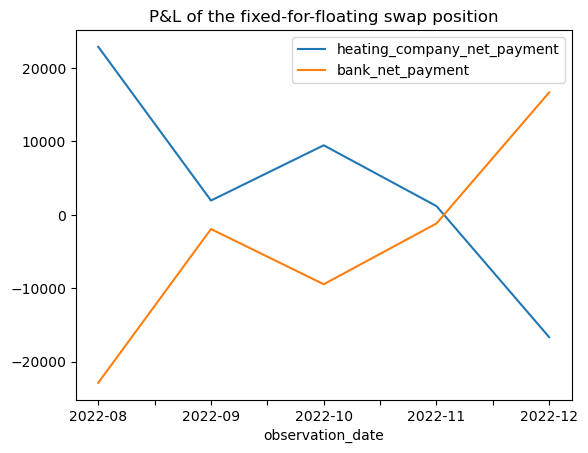

In [370]:
# This is the theoretical PnL for long forward

# Plot multiple line plots using only pandas
df_B_monthly.plot(x='observation_date', y=['heating_company_net_payment', 'bank_net_payment'], 
        kind='line', 
        title='P&L of the fixed-for-floating swap position');

# Part C: Options
 
Create Option Payoffs for the theoretical options:

A. Call:
- $S_0 = 100$
- $K = 105$
- Premium = $3
- T = 1 month
  
- What is Break-even price?
  
- What is ROI if in 1 month, the underlying price = $110? 

B. Put: 
- $S_0 = 100$
- $K = 95$
- Premium = $2
  
- T = 1 month
  
- What is Break-even price?
  
- What is ROI if in 1 month, the underlying price = $92


### A. Long Call:
- $S_0 = 100$
- $K = 105$
- Premium = $3
- T = 1 month
  
- What is Break-even price?
  
- What is ROI if in 1 month, the underlying price = $110? 

In [373]:
# Input: S_T, K, Premium, T, underlying price
# Output: Payoff, breakeven price, ROI

S_0 = 100


def long_call_option_payoff(S_T = 110, K = 105, Premium = 3):
    # Long Call
    if S_T > K:
        payoff = S_T - K
    else: 
        payoff = 0
    breakeven = K + Premium
    roi = round((payoff - Premium)/Premium * 100, 2)

    print(f"""
    With the following parameters of
    S_T: {S_T}
    K: {K}
    Premium = {Premium}

    For the Long Call we get the following values of
    Payoff: {payoff}
    Breakeven: {breakeven}
    ROI: {roi}%
    """)

In [374]:
# Test our function
long_call_option_payoff()


    With the following parameters of
    S_T: 110
    K: 105
    Premium = 3

    For the Long Call we get the following values of
    Payoff: 5
    Breakeven: 108
    ROI: 66.67%
    


### B. Put: 
- $S_0 = 100$
- $K = 95$
- Premium = $2
  
- T = 1 month
  
- What is Break-even price?
  
- What is ROI if in 1 month, the underlying price = $92

In [376]:
# Input: S_T, K, Premium, T, underlying price
# Output: Payoff, breakeven price, ROI

S_0 = 100


def long_put_option_payoff(S_T = 92, K = 95, Premium = 2):
    # Long Put
    if S_T < K:
        payoff = K - S_T
    else: 
        payoff = 0
    breakeven = K - Premium
    roi = round((payoff - Premium)/Premium * 100, 2)

    print(f"""
    With the following parameters of
    S_T: {S_T}
    K: {K}
    Premium = {Premium}

    For the Long Call we get the following values of
    Payoff: {payoff}
    Breakeven: {breakeven}
    ROI: {roi}%
    """)

In [377]:
long_put_option_payoff()


    With the following parameters of
    S_T: 92
    K: 95
    Premium = 2

    For the Long Call we get the following values of
    Payoff: 3
    Breakeven: 93
    ROI: 50.0%
    


# Part D: Futures Margining & Daily Mark-to-Market — **Gold (Short 1 COMEX Contract)**

A trader goes **short one gold futures contract** on COMEX.

- **Contract size:** 100 troy ounces  
- **Entry price (Day 0):** $1,920 per ounce
    
- **Initial margin:** $7,200
  
- **Maintenance margin:** $6,500  

The futures position is **short** (the trader benefits if gold prices fall).  
At the end of each trading day, the contract is **marked to market (MTM)**.  
If the margin account falls **below maintenance**, the trader must **top up back to the initial margin level**.

**Settlement Prices (per ounce):**

| Day | Price ($) |
|-----|-----------|
| 0   | 1,920     |
| 1   | 1,915     |
| 2   | 1,940     |
| 3   | 1,925     |
| 4   | 1,910     |

**Tasks**  
1. **Daily MTM**: Compute the daily profit or loss (P/L) for Days 1–4 and track the margin account balance day by day.  
2. **Margin Calls**: Identify days when the balance falls below maintenance; compute the deposit needed to restore to the **initial margin**.  
3. **Final Outcome**: Compute total net P/L at Day 4 and verify with a cash-flow check.  
4. **Discussion**: Explain why a short faces margin calls when prices rise and how the clearinghouse ensures winners are paid.

In [379]:
day = [0, 1, 2, 3, 4]
price = [1920, 1915, 1940, 1925, 1910]

df_D = pd.DataFrame({'Day': day, 'Price ($)': price})
print(df_D)

   Day  Price ($)
0    0       1920
1    1       1915
2    2       1940
3    3       1925
4    4       1910


In [380]:
prev_day_price = price[0]
print(prev_day_price)

1920


In [381]:
print(df_D["Price ($)"][0])

1920


### **Task 1**: **Daily MTM** - Compute the daily profit or loss (P/L) for Days 1–4 and track the margin account balance day by day.  

### **Task 2**: **Margin Calls** - Identify days when the balance falls below maintenance; compute the deposit needed to restore to the **initial margin**.  

In [383]:
# Calculate MTM Loss per day
# Update the new balance
# If below maintenance margin level top up margin account to restore to initial level

initial_margin = 7200
maintenance_margin_value = 6500
contract_size = 100

daily_mtm = []
margin_account_value = []
margin_call_triggured = []

for i in df_D.index:
    # Task 1: Daily MTM
    mtm_day_i = (prev_day_price-df_D["Price ($)"][i])*contract_size
    daily_mtm.append(mtm_day_i)

    # Update the previous day's price for subsequent iterations
    prev_day_price = df_D["Price ($)"][i]

    # Task 2: Margin Calls
    initial_margin += mtm_day_i

    is_called_triggered = "No"
    if(initial_margin < maintenance_margin_value):
        value_to_add = 7200 - initial_margin
        initial_margin += value_to_add
        is_called_triggered = f"Yes ${value_to_add} has been added"
        
    margin_account_value.append(initial_margin)
    margin_call_triggured.append(is_called_triggered)
    
df_D['daily_mtm'] = daily_mtm
df_D['margin_account_value'] = margin_account_value
df_D['margin_call_triggured'] = margin_call_triggured

df_D

,Day,Price ($),daily_mtm,margin_account_value,margin_call_triggured
0,0,1920,0,7200,No
1,1,1915,500,7700,No
2,2,1940,-2500,7200,Yes $2000 has been added
3,3,1925,1500,8700,No
4,4,1910,1500,10200,No


### **Task 3**: **Final Outcome** - Compute total net P/L at Day 4 and verify with a cash-flow check.  

Total Net P/L

In [386]:
net_PnL = df_D['margin_account_value'][len(df_D)-1] - df_D['margin_account_value'][0] 
net_PnL

3000

In [387]:
print(len(df_D))

5


Cash-flow check

In [390]:
output = 0
for i, row in df_D.iterrows():
    # To account for daily MTM
    output += df_D['daily_mtm'][i]
    
    # To account for Margin Call
    if df_D['margin_call_triggured'][i] == "No":
        continue
    else:
        output += float(df_D['margin_call_triggured'][i][5:9])
        
    
print(output)

3000.0


### **Task 4**: **Discussion** - Explain why a short faces margin calls when prices rise and how the clearinghouse ensures winners are paid.

A short position faces margin calls when prices rise because there will be a deduction in the margin account. If the deduction is large enough such that value in margin account falls below maintenance margin levels this would cause the margin call to be triggered. As a result, the person who's margin account this happens it would then need to top up the balance such that the value in the margin account goes back into the initial margin level of $7,200 in our case.

Whereas how the clearinghouse ensures that winners are paid is that it acts as the guarantor that provides clearning and settlement services that guaranteers the contract performance. The clearing house acts as the intermediary between every trade and becomes the buyer to every seller and seller to every buyer. Thereby this would help ensure that winning posuitions are paid and losig positions are paid up thereby reducing the counterparty risk.
